# ML Model Metrics

## Classification Metrics

### Example

In [16]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, average_precision_score, precision_recall_curve

In [4]:
# Define number of entries
num_entries = 300

# Feature data
X = pd.DataFrame({
    'feature_1': np.random.normal(0, 1, num_entries),
    'feature_2': np.random.normal(5, 2, num_entries),
    'feature_3': np.random.normal(-3, 3, num_entries)
})

# Class data
y = (X['feature_1'] + X['feature_2'] > 5).astype(int)

# Report
print(f'Feature data:\n{X[0:5]}')
print()
print(f'Class data:\n{y[0:5]}')

Feature data:
   feature_1  feature_2  feature_3
0   0.685488   5.503924   2.978488
1  -0.134550   3.759443   0.281136
2  -0.830364   3.444301   1.188601
3  -0.103172   4.982922  -2.034775
4  -0.868481   7.898612  -0.831414

Class data:
0    1
1    0
2    0
3    0
4    1
dtype: int64


In [5]:
# Split data
X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size = 0.8, test_size = 0.2, random_state = 0)

# Define
model = RandomForestClassifier()
# Fit model
model.fit(X_train, y_train)
# Generate predictions
y_pred = model.predict(X_valid)

### Accuracy

Accuracy describes the propoertion of correct predictions, and can be applied when:
- Classes are balanced
- Misclassification costs are equal

In [6]:
# Calculate accuracy
accuracy = accuracy_score(y_valid, y_pred)
print(f'Accuracy Score: {accuracy}')

Accuracy Score: 0.9333333333333333


### F1 Score

F1 score is the harmonic mean of precision and recall, and can be applied when:
- Classes are imbalanced
- You care about false positives and false negatives

In [7]:
# Calculate F1 score
f1 = f1_score(y_valid, y_pred)
print(f'F1 Score: {f1}')

F1 Score: 0.9333333333333333


### ROC-AUC

ROC-AUC score is used for binary classification problems (e.g. disease vs no disease), and is useful when:
- Classes are imbalanced
- You care about ranking positive cases above negative cases

In [8]:
# Calculate ROC score
y_prob = model.predict_proba(X_valid)[:, 1]
auc = roc_auc_score(y_valid, y_prob)
print(f'ROC-AUC: {auc}')

ROC-AUC: 0.9899888765294772


The ROC-AUC curve plots:
- True Positive Rate (TPR) on the y-axis
- False Positive Rate (FPR) on the x-axis

for all possible probability thresholds 0-1, showing differences in model behaviour when decision boundary is varied. This answers the question:

_If I randomly pick one positive and one negative sample, what is the probability the model assigns a higher score to the positive one?_

AUC is the area under the ROC curve, summarising model's ranking ability:
- 1.0 = perfect ranking
- 0.5 = random guessing
- < 0.5 = worse than random

Accuracy, F1, precision and recall all depend on choosing a single threshold. ROC-AUC evaluates the model across all thresholds.

ROC-AUC may not be useful if classes are **extremely** imbalanced (e.g. 0.1% positive), as FPR barely changes.

Here, **Precision-Recall AUC** may be more informative.

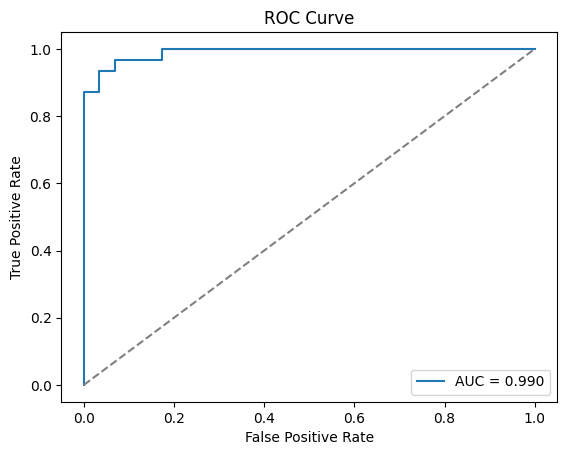

In [ ]:
fpr, tpr, thresholds = roc_curve(y_valid, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Precision-Recall AUC (PR-AUC)

PR-AUC summarises how well a model identifies a binary positive class when positives are **rare**. ROC-AUC considers both classes equally.

In [15]:
# Calculate PR-AUC
y_prob = model.predict_proba(X_valid)[:, 1]
pr_auc = average_precision_score(y_valid, y_prob)
print(f'Precision-Recall AUC: {pr_auc}')

Precision-Recall AUC: 0.9913159683599061


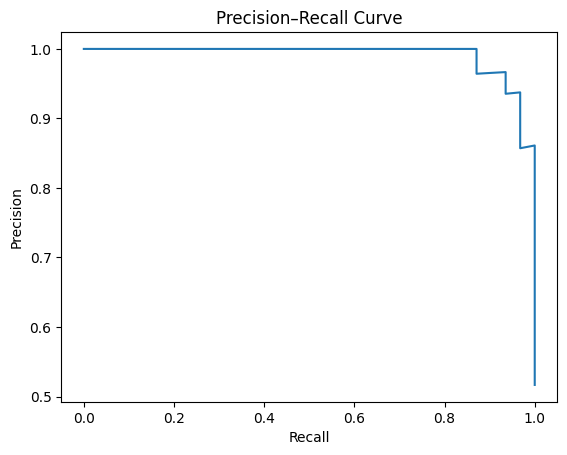

In [17]:
precision, recall, thresholds = precision_recall_curve(y_valid, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.show()

## Regression Metrics

### Example

In [25]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [26]:
# Define number of entries
num_entries = 300

# Feature data
X = pd.DataFrame({
    'feature_1': np.random.normal(0, 1, num_entries),
    'feature_2': np.random.normal(10, 5, num_entries),
    'feature_3': np.random.uniform(0, 20, num_entries)
})

# Continuous data
y = (
    3 * X["feature_1"]
    - 0.5 * X["feature_2"]
    + 0.8 * X["feature_3"]
    + np.random.normal(0, 2, num_entries)
)

# Report
print(f'Feature data:\n{X[0:5]}')
print()
print(f'Continuous data:\n{y[0:5]}')

Feature data:
   feature_1  feature_2  feature_3
0   0.518394  15.650770   6.293649
1   1.949160  11.328067   9.894649
2  -0.648594   2.344644  11.797951
3  -0.019936  12.046334  15.756148
4  -1.286822  11.005213   1.070283

Continuous data:
0    -8.151331
1    10.909486
2     6.330852
3     9.373653
4   -13.995946
dtype: float64


In [27]:
# Split data
X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size = 0.8, test_size = 0.2, random_state = 0)
# Define model
model = RandomForestRegressor()
# Fit model
model.fit(X_train, y_train)
# Generate predictions
y_pred = model.predict(X_valid)

### MSE

Average squared difference between predicted and actual values.
- Penalises large errors heavily

In [28]:
# Calculate mean squared error
mse = mean_squared_error(y_valid, y_pred)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 5.5236002886040145


### $R^2$

Proportion of variance explained by the model.

In [29]:
# Calculate r2
r2 = r2_score(y_valid, y_pred)
print(f'R2 score: {r2}')

R2 score: 0.8816491871870331
